# Goal

Decomposite the orbital decay curve into trend and seasonal components usint Lomb-Scargle and STL.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from utils.data_loader import find_repo_root
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from utils.data_loader import load_parquet
from utils.plot_loader import plot_lombscargle_periodogram

# Data

In [2]:
# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


Lets have a look at the raw data:

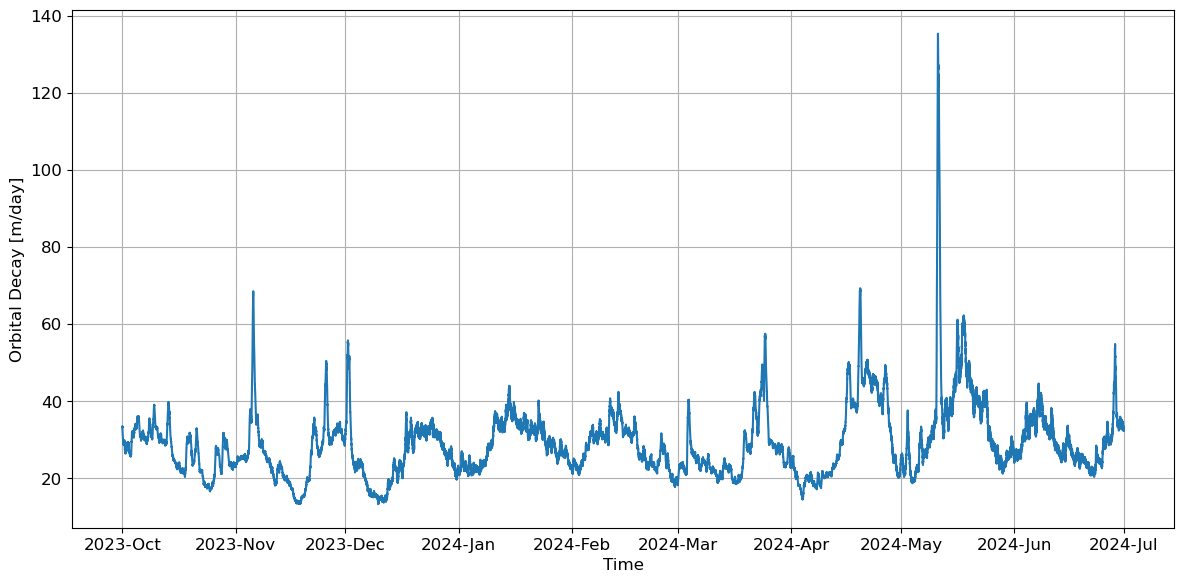

In [3]:
from utils.plot_loader import plot_orbital_decay

# =========================== Input ===================================
start_date = '2023-10-01 00:00:00'
end_date = '2024-07-01 00:00:00'
# start_date = pd.to_datetime(GFOC_data['time'].iloc[0])
# end_date = pd.to_datetime(GFOC_data['time'].iloc[-1]) #removed gap by ignoring the last 4321 values (for csv)

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

Flags = False

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=Flags)

# STL filter

In [4]:
def stl_decomposition(y, day):
    period = int(day * 24 * 60 * 3) # 1: 22.77 days, 2: 
    print(f"using a period of {period/(180*24)} days")
    seasonal = 100 * period + ((100*period % 2) == 0)  # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period + 1))
    trend_jump = int(0.15 * 1.5 * (period + 1))


    mod = STL(
        y['orbital_decay'],
        period=period,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
        seasonal_deg=0,
        robust=True
    )
    %timeit mod.fit()
    res = mod.fit()

    # plot
    plt.rc("figure", figsize=(12, 10))
    plt.rc("font", size=13)
    fig = res.plot()
    return res

## 1. Remove trend using STL decomposition

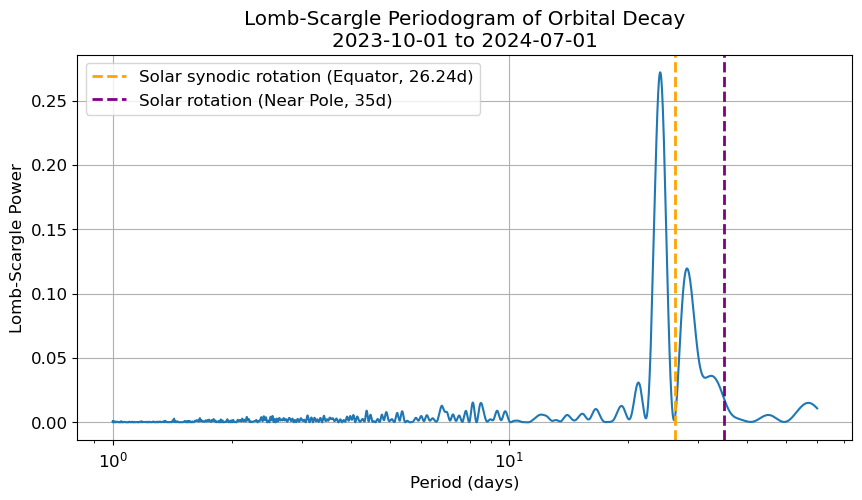

1. Period: 24.0987 +0.9204 -0.9227 days
2. Period: 28.1630 +1.6736 -1.1663 days
3. Period: 32.3980 +2.5654 -5.8730 days
4. Period: 21.2309 +0.5370 -0.5652 days
5. Period: 8.1122 +0.0865 -0.0864 days
6. Period: 57.0066 +2.9934 -3.8999 days
7. Period: 8.5015 +0.1487 -0.1143 days
8. Period: 6.7769 +0.2361 -0.1023 days
9. Period: 19.2387 +0.5191 -0.5412 days
10. Period: 16.5763 +0.4144 -0.4033 days


In [15]:
# Use time as index for y
GFOC_subset = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)].copy()
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    show=False
)

In [ ]:
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_1 = stl_decomposition(y, 24.1)

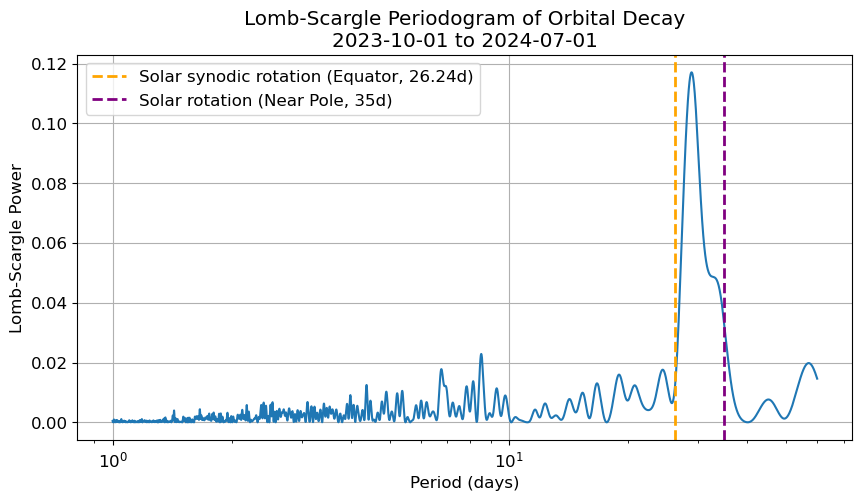

1. Period: 28.9158 +2.2304 -1.6513 days
2. Period: 8.5179 +0.1272 -0.1126 days
3. Period: 57.1026 +2.8974 -4.0236 days
4. Period: 6.7567 +0.2405 -0.0912 days
5. Period: 24.4521 +0.9579 -0.9657 days
6. Period: 18.9731 +0.7691 -0.6065 days
7. Period: 8.1284 +0.0866 -0.0950 days
8. Period: 16.6933 +0.4289 -0.3933 days
9. Period: 4.3745 +0.0275 -0.0282 days
10. Period: 20.7797 +0.9058 -2.5088 days


In [6]:
# GFOC_subset['trend_1'] = res_1.trend.values
GFOC_subset['seasonal_1'] = res_1.seasonal.values
GFOC_subset['residual'] = res_1.resid.values + res_1.trend.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']
# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    show=False
)

## 2. Remove Periodic Signal and non-linear Trend

using a period of 28.919907407407408 days
1min 41s ± 3.17 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


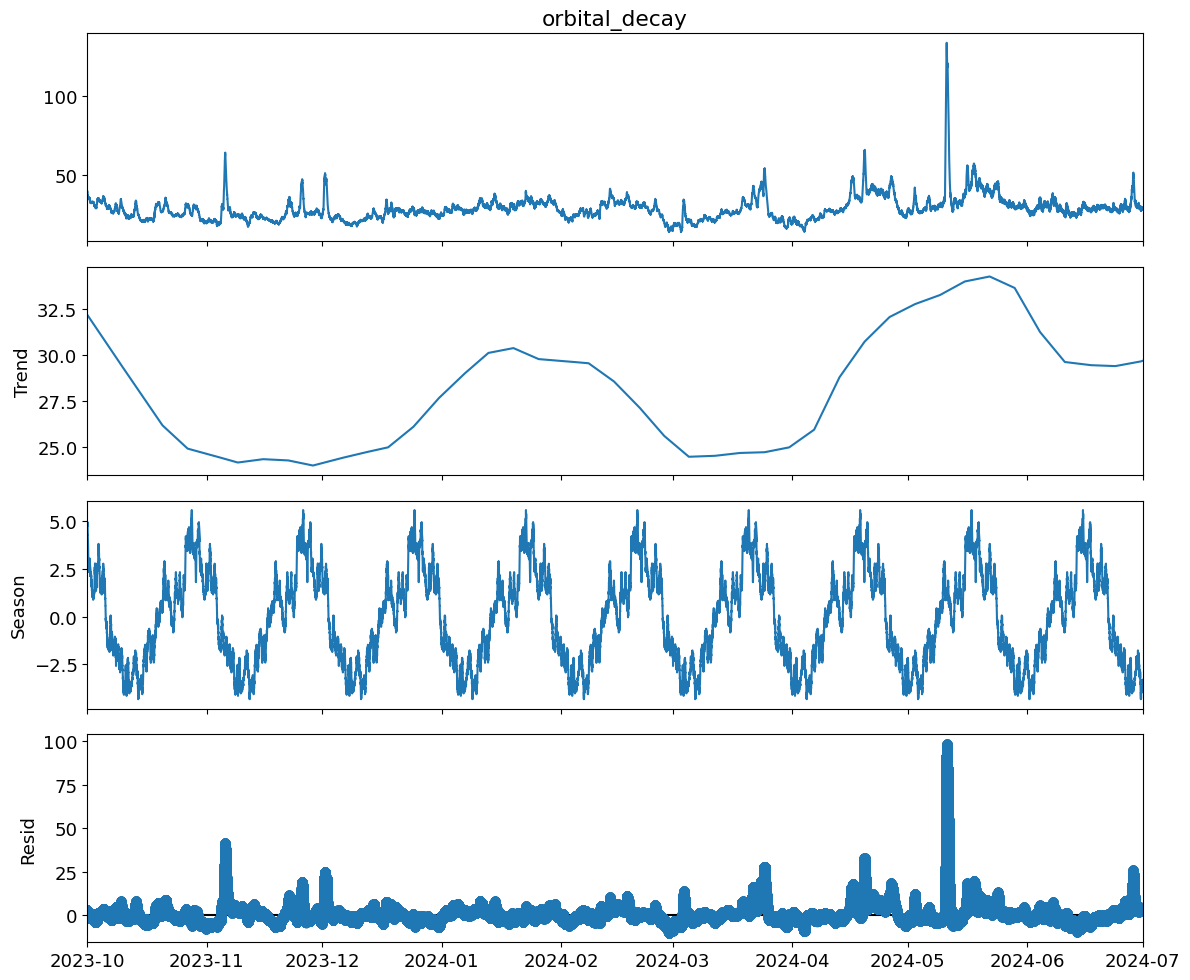

In [7]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_2 = stl_decomposition(y, 28.92)

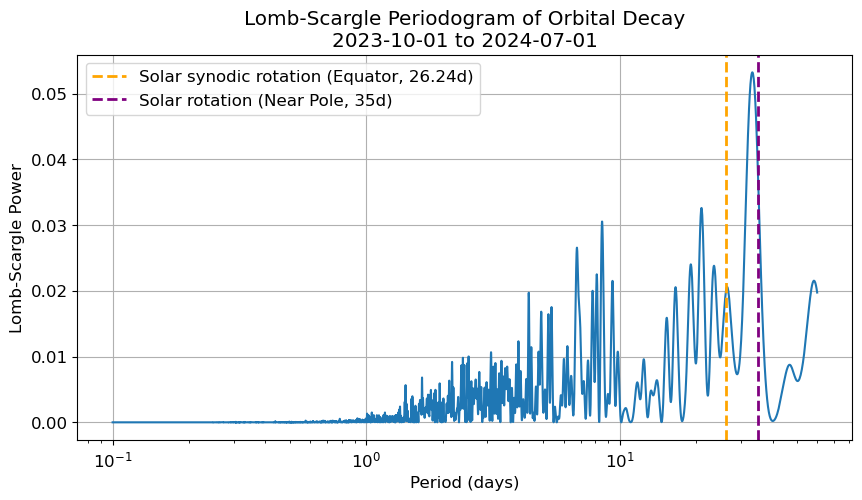

1. Period: 33.2840 +2.4723 -2.2674 days
2. Period: 21.0016 +0.6449 -0.6817 days
3. Period: 8.5107 +0.1407 -0.1212 days
4. Period: 6.7728 +0.2260 -0.1082 days
5. Period: 19.0450 +0.6349 -0.5963 days
6. Period: 23.5163 +0.9882 -0.8000 days
7. Period: 8.1110 +0.0900 -0.0973 days
8. Period: 58.2552 +1.7448 -4.9594 days
9. Period: 9.3531 +0.1352 -0.1377 days
10. Period: 26.5029 +1.5950 -1.4579 days


In [8]:
GFOC_subset['trend_1'] = res_2.trend.values
GFOC_subset['seasonal_2'] = res_2.seasonal.values
GFOC_subset['residual'] = res_2.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=60,  # days
    show=False
)

## 3. Remove secondary seasonal components

using a period of 33.27986111111111 days
1min 29s ± 2.39 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


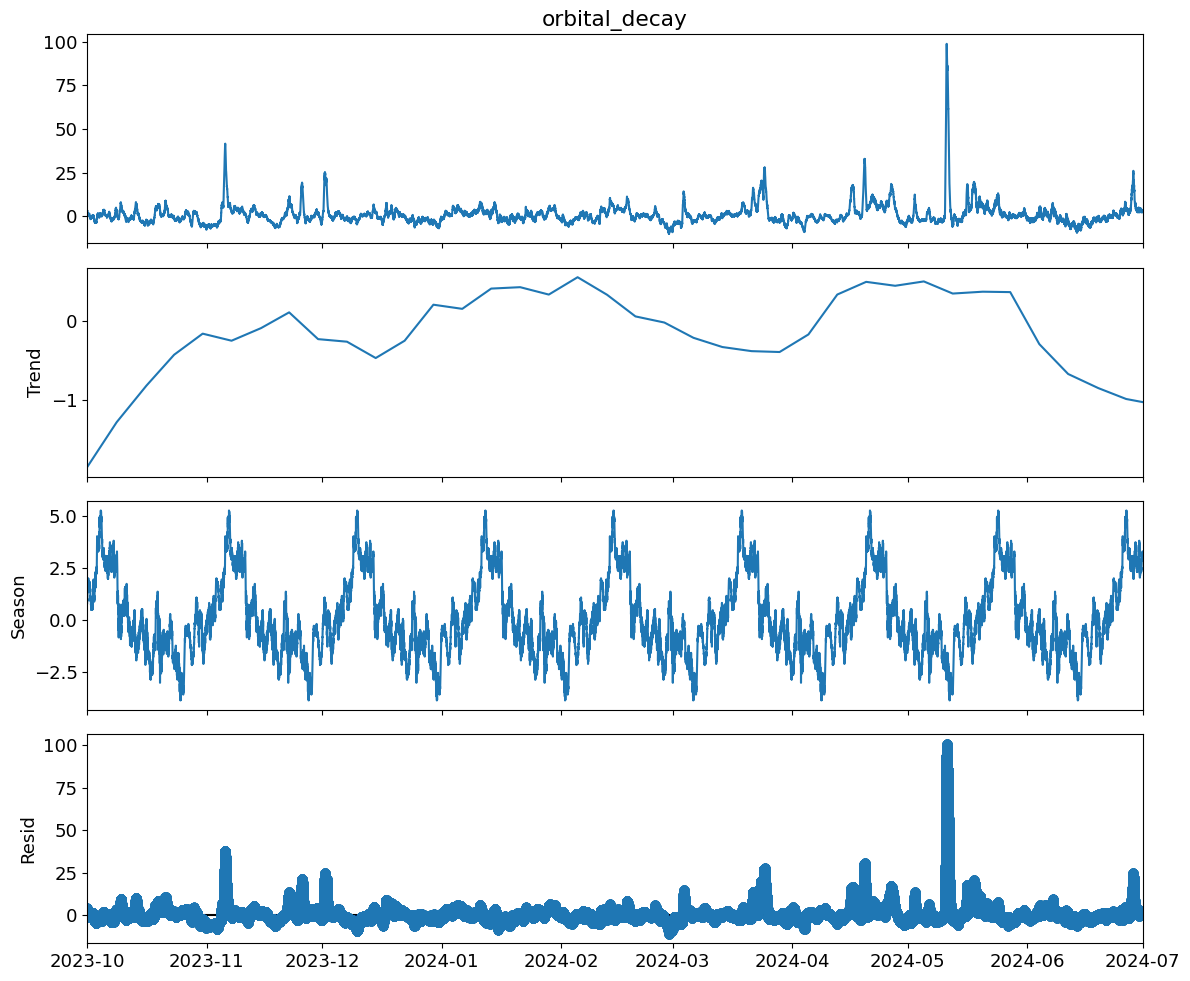

In [9]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_3 = stl_decomposition(y, 33.28)

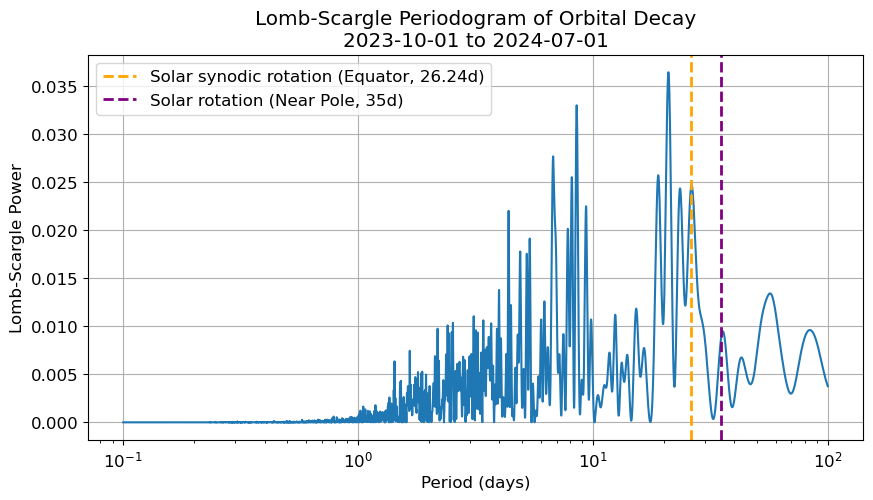

1. Period: 20.9808 +0.6403 -0.7219 days
2. Period: 8.5256 +0.1272 -0.1146 days
3. Period: 6.7676 +0.2364 -0.1125 days
4. Period: 18.9546 +0.6878 -0.6248 days
5. Period: 8.1309 +0.0937 -0.1107 days
6. Period: 26.3350 +1.8991 -1.5026 days
7. Period: 23.4920 +1.1996 -0.7989 days
8. Period: 9.3455 +0.1365 -0.1375 days
9. Period: 4.3748 +0.0273 -0.0285 days
10. Period: 7.8196 +0.1060 -0.0965 days


In [10]:
GFOC_subset['trend_2'] = res_3.trend.values
GFOC_subset['seasonal_3'] = res_3.seasonal.values
GFOC_subset['residual'] = res_3.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=100,  # days
    show=False
)

# Plot Results

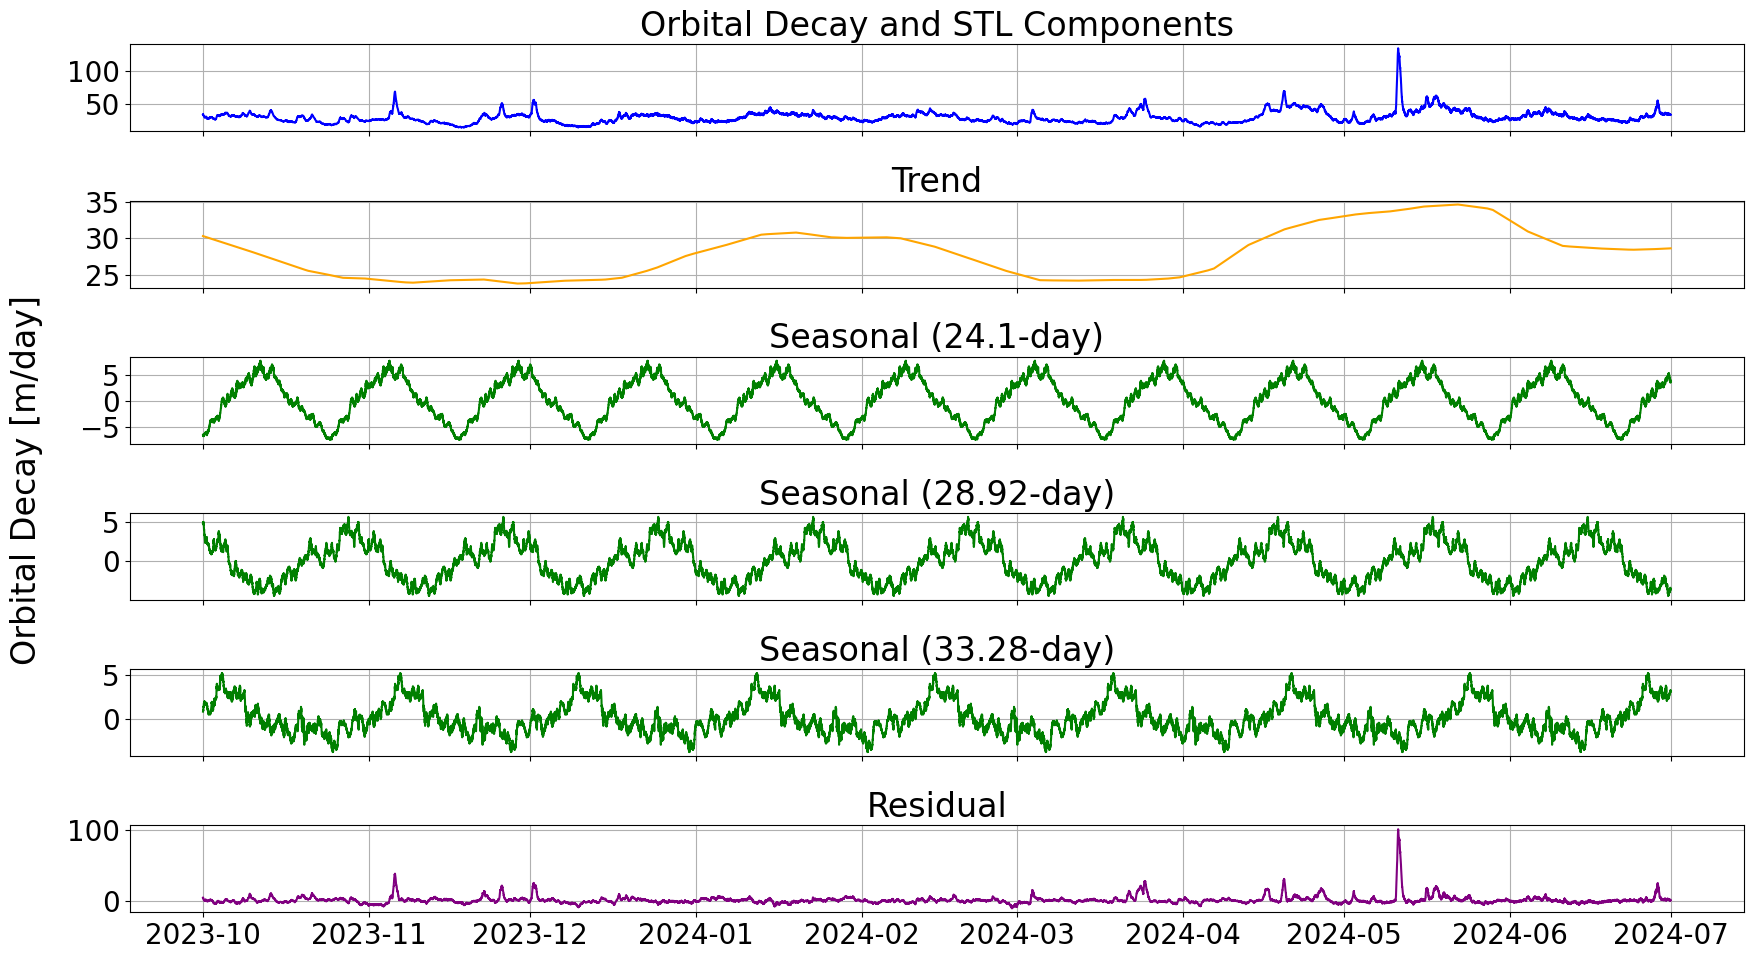

In [14]:
# set font & label size
plt.rcParams.update({'font.size': 20})

GFOC_subset['original_decay'] = GFOC_data['orbital_decay'].where(GFOC_data['time'].isin(GFOC_subset['time']))
# plot components
fig, axs = plt.subplots(6, 1, figsize=(18, 10), sharex=True)
axs[0].plot(GFOC_subset['time'], GFOC_subset['original_decay'], color='blue')
axs[0].set_title('Orbital Decay and STL Components')

axs[1].plot(GFOC_subset['time'], GFOC_subset['trend_1'] + GFOC_subset['trend_2'], color='orange')
axs[1].set_title('Trend')

axs[2].plot(GFOC_subset['time'], GFOC_subset['seasonal_1'], color='green')
axs[2].set_title('Seasonal (24.1-day)')

axs[3].plot(GFOC_subset['time'], GFOC_subset['seasonal_2'], color='green')
axs[3].set_title('Seasonal (28.92-day)')

axs[4].plot(GFOC_subset['time'], GFOC_subset['seasonal_3'], color='green')
axs[4].set_title('Seasonal (33.28-day)')

axs[5].plot(GFOC_subset['time'], GFOC_subset['residual'], color='purple')
axs[5].set_title('Residual')

for ax in axs:
    # ax.legend()
    ax.grid()
# plt.xlabel('time')
fig.supylabel('Orbital Decay [m/day]')
plt.tight_layout()
plt.show()